In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score


/tmp/ipykernel_18282/4047390210.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_synth[:,0], X_synth[:,1], s=50, cmap='viridis')


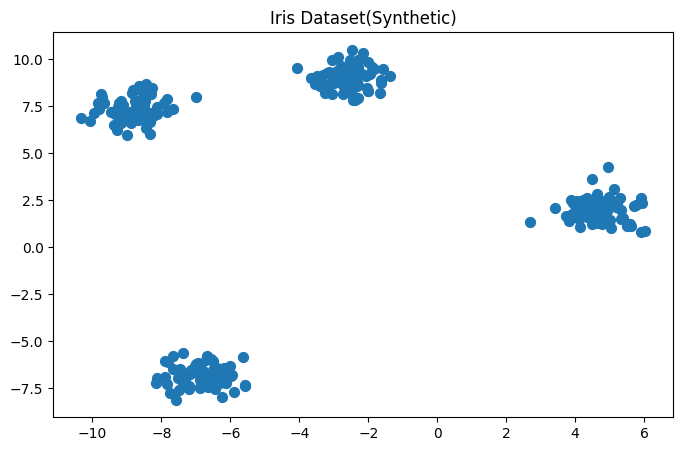

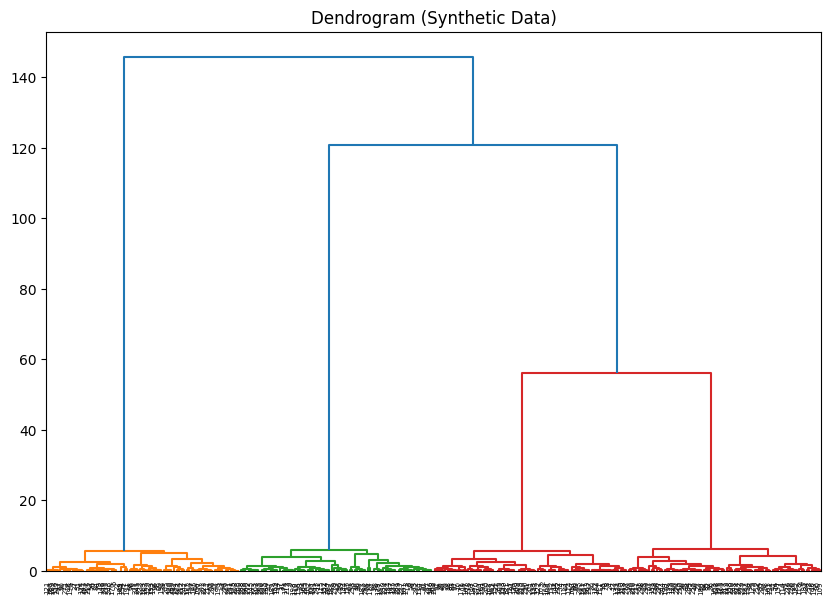

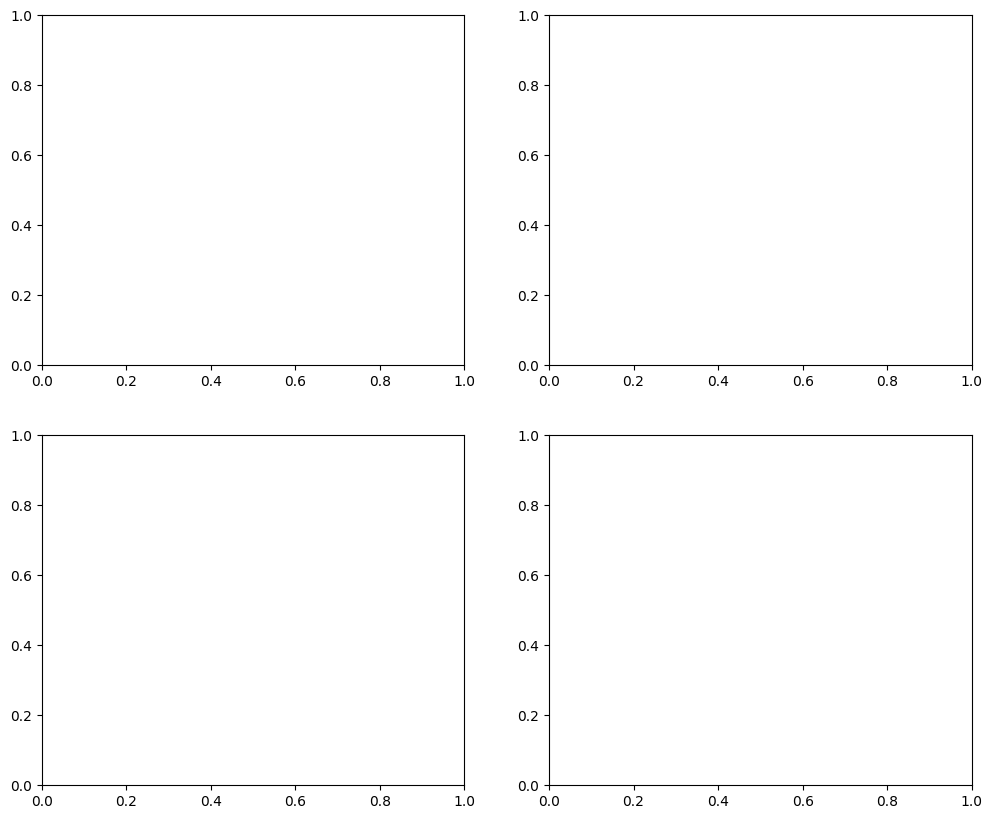

In [2]:

#creating dataset
X_synth, y_synth = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

plt.figure(figsize=(8,5))
plt.scatter(X_synth[:,0], X_synth[:,1], s=50, cmap='viridis')
plt.title("Iris Dataset(Synthetic)")
plt.show()

plt.figure(figsize=(10, 7))
plt.title("Dendrogram (Synthetic Data)")
z_synth = linkage(X_synth, method='ward')
dendrogram(z_synth)
plt.show()

linkage_methods = ['single', 'complete','average','ward']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

In [3]:
for i, method in enumerate(linkage_methods):
    hc = AgglomerativeClustering(n_clusters=3, linkage=method)
    y_hc = hc.fit_predict(X_synth)


    ax = axes[i // 2, i % 2]
    ax.scatter(X_synth[:, 0], X_synth[:, 1], c=y_hc, cmap='viridis', s=50)
    ax.set_title(f'Linkage Method: {method}')
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

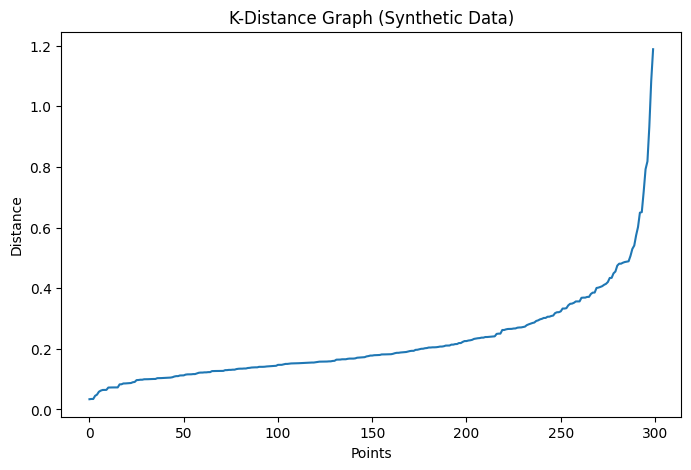

In [4]:
# K-Distance Graph for DBSCAN eps parameter
min_samples_synth = 3
nearest_neighbors = NearestNeighbors(n_neighbors=min_samples_synth)
nearest_neighbors_fit = nearest_neighbors.fit(X_synth)
distances, indices = nearest_neighbors_fit.kneighbors(X_synth)

#sorting distance by the k-th nearest neighbor
distances = np.sort(distances[:, min_samples_synth - 1], axis=0)

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel('Points')
plt.ylabel('Distance')
plt.title('K-Distance Graph (Synthetic Data)')
plt.show()

ValueError: 'c' argument has 300 elements, which is inconsistent with 'x' and 'y' with size 280.

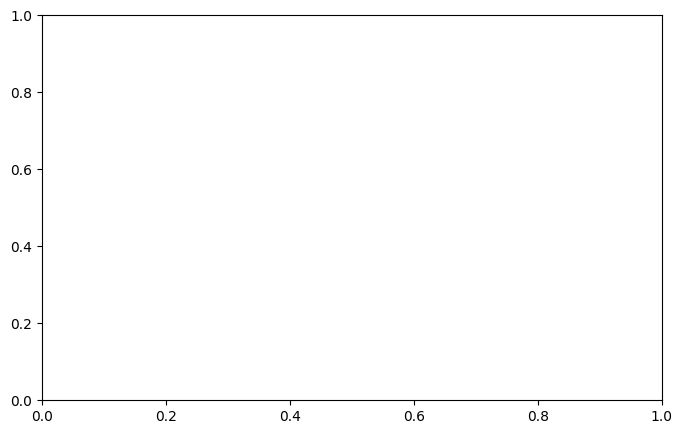

In [5]:
# DBSCAN Implementation

dbscan_synth = DBSCAN(eps=0.4, min_samples=min_samples_synth)
y_dbscan_synth = dbscan_synth.fit_predict(X_synth)

#Visualize DBSCAN
plt.figure(figsize=(8, 5))
plt.scatter(X_synth[y_dbscan_synth != -1, 0], X_synth[y_dbscan_synth !=-1,1], c=[y_dbscan_synth != -1],  cmap='viridis', s=50, label='Cluster')
noise_mask = (y_dbscan_synth == -1)
plt.scatter(X_synth[noise_mask, 0], X_synth[noise_mask, 1], c='red', s=50, label='Noise')
plt.title('DBSCAN Clustering (Synthetic Data)')
plt.legend()
plt.show()